# Toxic Comment Severity Ranking Using Machine Learning

## Project Overview

Online communities generate massive volumes of user generated content every day. Moderating harmful content manually is difficult, time consuming, and often inconsistent.

This project applies Natural Language Processing (NLP) and Machine Learning techniques to rank online comments according to their toxicity severity. Rather than predicting whether a comment is toxic or non-toxic, the objective is to assign toxicity scores that correctly order comments from less toxic to more toxic.

The project uses the Kaggle Jigsaw Toxic Severity Rating dataset. Comments are converted into numerical representations using TF-IDF (Term Frequency–Inverse Document Frequency) vectorization and used to train ranking-based machine learning models.

A pairwise learning approach is employed, where the model learns relative toxicity from pairs of comments labeled as less toxic and more toxic. Performance is evaluated using Ranking Accuracy, which measures how often the model correctly orders comment pairs.

The final goal is to build a toxicity ranking system that can automatically prioritize harmful content for moderation and assist online platforms in maintaining healthier communities.

---

## Kaggle Competition Information

**Competition:** Jigsaw Toxic Severity Rating

**Objective:** Assign a toxicity score to each comment so that more toxic comments receive higher scores than less toxic comments.

**Evaluation Metric:** Pairwise Ranking Accuracy

**Dataset Files:**

* comments_to_score.csv
* validation_data.csv

---

## Technologies Used

- Python
- Pandas
- NumPy
- Scikit-Learn
- Matplotlib
- Jupyter Notebook
- TF-IDF Vectorization

---

# Models Evaluated

## Traditional Models

- Logistic Regression
- LinearSVC

## Advanced Models

- SGDClassifier
- PassiveAggressiveClassifier
- RidgeClassifier

## Model Selection Strategy

All candidate models are trained using identical TF-IDF features and pairwise ranking labels.

Each model is evaluated using Pairwise Ranking Accuracy on the validation dataset.

The model achieving the highest ranking accuracy is selected as the final ranking model and used to generate the Kaggle submission file.


## Final Ranking Model

The best performing ranking model is automatically selected based on Pairwise Ranking Accuracy.

The final model is used to score all Kaggle comments and generate the submission file.

The final ranking model is selected automatically after evaluating all candidate models.

In [1]:
# ----------------------------------
# Import Libraries
# ----------------------------------

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer

print("Libraries loaded successfully.")

Libraries loaded successfully.


# Dataset Loading

In this section, the Jigsaw Toxic Severity Rating datasets are loaded into memory using Pandas.

The competition provides two files:

### comments_to_score.csv

Contains comments that require toxicity scores. The model will assign a continuous toxicity score to each comment for ranking purposes.

### validation_data.csv

Contains pairs of comments labeled as **less toxic** and **more toxic**. These pairs are used to train and evaluate ranking models.

The objectives of this section are:

* Load both datasets
* Examine dataset structure
* Verify column names and data types
* Check for missing values
* Identify duplicate records
* Generate basic dataset statistics

Understanding the datasets before preprocessing helps ensure data quality and prevents issues during feature engineering and model training.


In [2]:
# ----------------------------------
# Load Dataset
# ----------------------------------

comments_df = pd.read_csv("../data/comments_to_score.csv")

validation_df = pd.read_csv("../data/validation_data.csv")

print("Comments Dataset Shape:")
print(comments_df.shape)

print("\nValidation Dataset Shape:")
print(validation_df.shape)

Comments Dataset Shape:
(7537, 2)

Validation Dataset Shape:
(30108, 3)


In [3]:
# ----------------------------------
# Preview Dataset
# ----------------------------------

print("Comments Dataset:")
display(comments_df.head())

print("\nValidation Dataset:")
display(validation_df.head())

Comments Dataset:


,comment_id,text
0,114890,"""\n \n\nGjalexei, you asked about whether ther..."
1,732895,"Looks like be have an abuser , can you please ..."
2,1139051,I confess to having complete (and apparently b...
3,1434512,"""\n\nFreud's ideas are certainly much discusse..."
4,2084821,It is not just you. This is a laundry list of ...



Validation Dataset:


,worker,less_toxic,more_toxic
0,313,This article sucks \n\nwoo woo wooooooo,WHAT!!!!!!!!?!?!!?!?!!?!?!?!?!!!!!!!!!!!!!!!!!...
1,188,"""And yes, people should recognize that but the...",Daphne Guinness \n\nTop of the mornin' my fav...
2,82,"Western Media?\n\nYup, because every crime in...","""Atom you don't believe actual photos of mastu..."
3,347,And you removed it! You numbskull! I don't car...,You seem to have sand in your vagina.\n\nMight...
4,539,smelly vagina \n\nBluerasberry why don't you ...,"hey \n\nway to support nazis, you racist"


In [4]:
# ----------------------------------
# Dataset Statistics
# ----------------------------------

print("Number of Comments:",
      len(comments_df))

print("Number of Validation Pairs:",
      len(validation_df))

print("\nColumns in Comments Dataset:")
print(comments_df.columns.tolist())

print("\nColumns in Validation Dataset:")
print(validation_df.columns.tolist())

Number of Comments: 7537
Number of Validation Pairs: 30108

Columns in Comments Dataset:
['comment_id', 'text']

Columns in Validation Dataset:
['worker', 'less_toxic', 'more_toxic']


In [5]:
# ----------------------------------
# Missing Values
# ----------------------------------

print("Comments Dataset Missing Values:")
print(comments_df.isnull().sum())

print("\nValidation Dataset Missing Values:")
print(validation_df.isnull().sum())

Comments Dataset Missing Values:
comment_id    0
text          0
dtype: int64

Validation Dataset Missing Values:
worker        0
less_toxic    0
more_toxic    0
dtype: int64


In [6]:
# ----------------------------------
# Duplicate Analysis
# ----------------------------------

print("Unique Comments:")
print(comments_df["comment_id"].nunique())

print("\nDuplicate Comment IDs:")
print(comments_df["comment_id"].duplicated().sum())

print("\nUnique Validation Workers:")
print(validation_df["worker"].nunique())

Unique Comments:
7537

Duplicate Comment IDs:
0

Unique Validation Workers:
753


In [7]:
# ----------------------------------
# Dataset Summary Table
# ----------------------------------

dataset_summary = pd.DataFrame({
    "Metric": [
        "Comments to Score",
        "Validation Pairs",
        "Comment Columns",
        "Validation Columns",
        "Missing Values (Comments)",
        "Missing Values (Validation)"
    ],

    "Value": [
        len(comments_df),
        len(validation_df),
        len(comments_df.columns),
        len(validation_df.columns),
        comments_df.isnull().sum().sum(),
        validation_df.isnull().sum().sum()
    ]
})

display(dataset_summary)

,Metric,Value
0,Comments to Score,7537
1,Validation Pairs,30108
2,Comment Columns,2
3,Validation Columns,3
4,Missing Values (Comments),0
5,Missing Values (Validation),0


In [8]:
# ----------------------------------
# Dataset Shapes Summary
# ----------------------------------

shape_summary = pd.DataFrame({
    "Dataset": [
        "comments_to_score",
        "validation_data"
    ],

    "Rows": [
        comments_df.shape[0],
        validation_df.shape[0]
    ],

    "Columns": [
        comments_df.shape[1],
        validation_df.shape[1]
    ]
})

display(shape_summary)

,Dataset,Rows,Columns
0,comments_to_score,7537,2
1,validation_data,30108,3


### Dataset Loading Summary

Both datasets were loaded successfully and contain no missing values.

The comments dataset contains individual comments that require toxicity scores, while the validation dataset contains pairwise toxicity comparisons used for ranking model development.

No duplicate comment identifiers were detected, indicating good data quality. The datasets are ready for exploratory data analysis and preprocessing.


# Exploratory Data Analysis (EDA)

Before building ranking models, it is important to understand the characteristics of the comments dataset.

Exploratory Data Analysis helps identify patterns, outliers, and text characteristics that may influence model performance.

In this section we will:

* Analyze comment lengths
* Analyze word counts
* Visualize text distributions
* Detect unusually short and long comments
* Identify outliers
* Generate descriptive statistics
* Understand the overall structure of the comment corpus

These insights help guide preprocessing and feature engineering decisions for toxicity severity ranking.


In [9]:
# ----------------------------------
# Comment Length Analysis
# ----------------------------------

comments_df["char_length"] = comments_df["text"].astype(str).apply(len)

print("Comment Length Statistics")

print(comments_df["char_length"].describe())

Comment Length Statistics
count    7537.000000
mean      417.804830
std       702.445639
min        21.000000
25%        87.000000
50%       188.000000
75%       431.000000
max      5000.000000
Name: char_length, dtype: float64


In [10]:
# ----------------------------------
# Word Count Analysis
# ----------------------------------

comments_df["word_count"] = (
    comments_df["text"]
    .astype(str)
    .apply(lambda x: len(x.split()))
)

print("Word Count Statistics")

print(comments_df["word_count"].describe())

Word Count Statistics
count    7537.000000
mean       72.005838
std       119.494230
min         2.000000
25%        15.000000
50%        33.000000
75%        75.000000
max      1250.000000
Name: word_count, dtype: float64


In [11]:
# ----------------------------------
# Comment Length Extremes
# ----------------------------------

extremes = pd.DataFrame({

    "Metric":[
        "Longest Comment (Words)",
        "Shortest Comment (Words)",
        "Longest Comment (Characters)",
        "Shortest Comment (Characters)"
    ],

    "Value":[
        comments_df["word_count"].max(),
        comments_df["word_count"].min(),
        comments_df["char_length"].max(),
        comments_df["char_length"].min()
    ]
})

display(extremes)

,Metric,Value
0,Longest Comment (Words),1250
1,Shortest Comment (Words),2
2,Longest Comment (Characters),5000
3,Shortest Comment (Characters),21


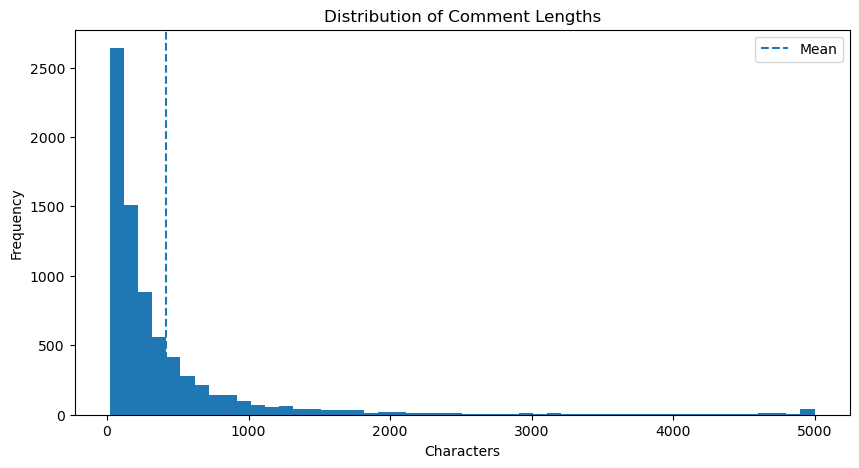

In [12]:
# ----------------------------------
# Character Length Distribution
# ----------------------------------

plt.figure(figsize=(10,5))

plt.hist(
    comments_df["char_length"],
    bins=50
)

plt.axvline(
    comments_df["char_length"].mean(),
    linestyle="--",
    label="Mean"
)

plt.title("Distribution of Comment Lengths")

plt.xlabel("Characters")

plt.ylabel("Frequency")

plt.legend()

plt.savefig(
    "../images/character_length_distribution.png",
    bbox_inches="tight"
)

plt.show()

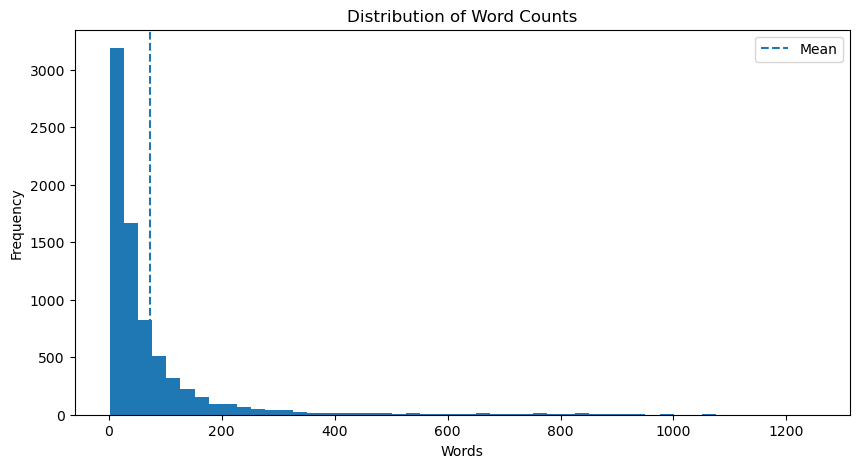

In [13]:
# ----------------------------------
# Word Count Distribution
# ----------------------------------

plt.figure(figsize=(10,5))

plt.hist(
    comments_df["word_count"],
    bins=50
)

plt.axvline(
    comments_df["word_count"].mean(),
    linestyle="--",
    label="Mean"
)

plt.title("Distribution of Word Counts")

plt.xlabel("Words")

plt.ylabel("Frequency")

plt.legend()

plt.savefig(
    "../images/word_count_distribution.png",
    bbox_inches="tight"
)

plt.show()

In [14]:
# ----------------------------------
# Top 10 Longest Comments
# ----------------------------------

longest_comments = (
    comments_df
    .sort_values(
        by="word_count",
        ascending=False
    )
    [["comment_id","word_count"]]
    .head(10)
)

display(longest_comments)

,comment_id,word_count
4572,257100648,1250
4910,280784896,1198
4570,257099998,1087
2630,144242734,1069
4948,283097815,1069
6488,403198200,1001
4174,230546005,1000
2392,129403021,1000
4571,257100444,1000
4180,230723384,996


In [15]:
# ----------------------------------
# Percentiles
# ----------------------------------

percentiles = pd.DataFrame({

    "Percentile":[
        "25%",
        "50%",
        "75%",
        "90%",
        "95%",
        "99%"
    ],

    "Word Count":[
        comments_df["word_count"].quantile(0.25),
        comments_df["word_count"].quantile(0.50),
        comments_df["word_count"].quantile(0.75),
        comments_df["word_count"].quantile(0.90),
        comments_df["word_count"].quantile(0.95),
        comments_df["word_count"].quantile(0.99)
    ]
})

display(percentiles)

,Percentile,Word Count
0,25%,15.0
1,50%,33.0
2,75%,75.0
3,90%,159.0
4,95%,261.0
5,99%,700.0


In [16]:
# ----------------------------------
# Dataset Summary
# ----------------------------------

summary = pd.DataFrame({

    "Metric":[
        "Total Comments",
        "Average Characters",
        "Average Words",
        "Median Words",
        "Maximum Words",
        "Minimum Words"
    ],

    "Value":[
        len(comments_df),
        round(comments_df["char_length"].mean(),2),
        round(comments_df["word_count"].mean(),2),
        comments_df["word_count"].median(),
        comments_df["word_count"].max(),
        comments_df["word_count"].min()
    ]
})

display(summary)

,Metric,Value
0,Total Comments,7537.00
1,Average Characters,417.80
2,Average Words,72.01
3,Median Words,33.00
4,Maximum Words,1250.00
5,Minimum Words,2.00


### Word Count Boxplot

A boxplot provides a compact summary of the distribution of comment lengths.

It shows:

- Median word count
- Interquartile Range (IQR)
- Minimum and maximum non-outlier values
- Potential outliers

This visualization helps identify unusually long comments that may influence feature engineering and model performance.

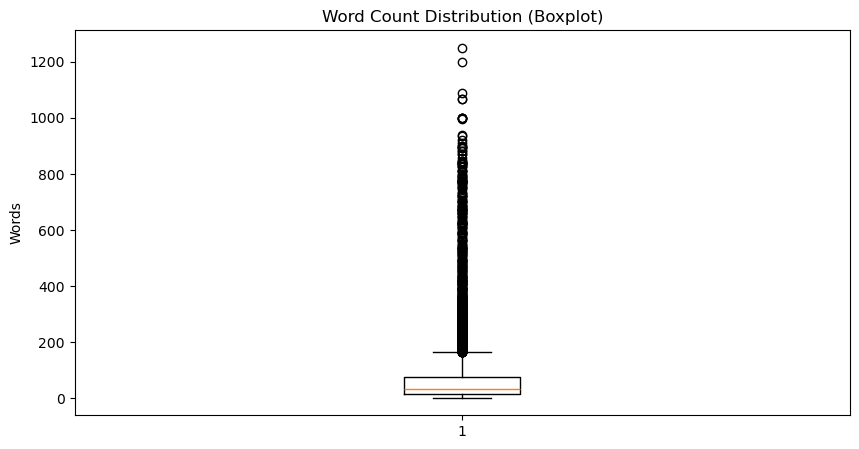

In [17]:
# ----------------------------------
# Word Count Boxplot
# ----------------------------------

plt.figure(figsize=(10,5))

plt.boxplot(
    comments_df["word_count"]
)

plt.title(
    "Word Count Distribution (Boxplot)"
)

plt.ylabel(
    "Words"
)

plt.savefig(
    "../images/boxplot_word_count.png",
    bbox_inches="tight"
)

plt.show()

### EDA Summary

The dataset contains comments with highly variable lengths, ranging from very short messages to extremely long discussions.

Both character counts and word counts exhibit strong right-skewed distributions, indicating that most comments are relatively short while a small number of comments are exceptionally long.

The presence of outliers suggests that text normalization and TF-IDF vectorization will be important for handling vocabulary variation effectively.

Overall, the dataset appears suitable for toxicity severity ranking and provides sufficient diversity for machine learning model development.


# Text Preprocessing

Raw text often contains inconsistencies that can negatively affect machine learning performance.

The objectives of preprocessing are to:

- Handle missing values
- Standardize text formatting
- Convert text to lowercase
- Remove extra whitespace
- Remove URLs and HTML tags
- Remove special characters
- Improve feature quality for TF-IDF vectorization

A clean and consistent text corpus improves the quality of extracted features and helps machine learning models better identify toxic language patterns.

In [18]:
# ----------------------------------
# Text Cleaning Libraries
# ----------------------------------

import re

In [19]:
# ----------------------------------
# Create Working Copy
# ----------------------------------

processed_df = comments_df.copy()

print("Dataset copied successfully.")

Dataset copied successfully.


In [20]:
# ----------------------------------
# Handle Missing Values
# ----------------------------------

processed_df["text"] = (
    processed_df["text"]
    .fillna("")
)

print(
    "Missing Values Remaining:",
    processed_df["text"].isnull().sum()
)

Missing Values Remaining: 0


In [21]:
# ----------------------------------
# Convert to Lowercase
# ----------------------------------

processed_df["clean_text"] = (
    processed_df["text"]
    .astype(str)
    .str.lower()
)

print("Lowercase conversion complete.")

Lowercase conversion complete.


In [22]:
# ----------------------------------
# Remove URLs
# ----------------------------------

processed_df["clean_text"] = (
    processed_df["clean_text"]
    .str.replace(
        r"http\S+|www\S+",
        "",
        regex=True
    )
)

print("URLs removed.")

URLs removed.


In [23]:
# ----------------------------------
# Remove HTML Tags
# ----------------------------------

processed_df["clean_text"] = (
    processed_df["clean_text"]
    .str.replace(
        r"<.*?>",
        "",
        regex=True
    )
)

print("HTML tags removed.")

HTML tags removed.


In [24]:
# ----------------------------------
# Remove Special Characters
# ----------------------------------

processed_df["clean_text"] = (
    processed_df["clean_text"]
    .str.replace(
        r"[^a-zA-Z\s]",
        " ",
        regex=True
    )
)

print("Special characters removed.")

Special characters removed.


In [25]:
# ----------------------------------
# Remove Extra Whitespace
# ----------------------------------

processed_df["clean_text"] = (
    processed_df["clean_text"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

print("Whitespace cleaned.")

Whitespace cleaned.


In [26]:
# ----------------------------------
# Before vs After
# ----------------------------------

for i in range(3):

    print("\nORIGINAL:")
    print(processed_df["text"].iloc[i][:200])

    print("\nCLEANED:")
    print(processed_df["clean_text"].iloc[i][:200])

    print("\n" + "-"*80)


ORIGINAL:
"
 

Gjalexei, you asked about whether there is an ""anti-editorializing"" policy here.  There is, and it's called wikipedia:neutral point of view.  It discusses at some length  the case of what we sh

CLEANED:
gjalexei you asked about whether there is an anti editorializing policy here there is and it s called wikipedia neutral point of view it discusses at some length the case of what we should do when wri

--------------------------------------------------------------------------------

ORIGINAL:
Looks like be have an abuser , can you please look into this?  thanks.

CLEANED:
looks like be have an abuser can you please look into this thanks

--------------------------------------------------------------------------------

ORIGINAL:
I confess to having complete (and apparently blissful) ignorance of Jordan, but I've glanced at the article. Is this a woman or a soap opera!?.  I don't think there was much to change in terms of the 

CLEANED:
i confess to having complete and 

In [27]:
# ----------------------------------
# Empty Comment Check
# ----------------------------------

empty_comments = (
    processed_df["clean_text"]
    .str.len()
    .eq(0)
    .sum()
)

print(
    "Empty Comments:",
    empty_comments
)

Empty Comments: 0


In [28]:
# ----------------------------------
# Final Text Corpus
# ----------------------------------

texts = processed_df["clean_text"]

print(
    "Total Comments:",
    len(texts)
)

print(
    "Example Comment:"
)

print(texts.iloc[0][:300])

Total Comments: 7537
Example Comment:
gjalexei you asked about whether there is an anti editorializing policy here there is and it s called wikipedia neutral point of view it discusses at some length the case of what we should do when writing about a subject which most of us find repugnant whilst you re not likely to get too many defend


In [29]:
# ----------------------------------
# Preprocessing Summary
# ----------------------------------

summary = pd.DataFrame({

    "Step":[
        "Missing Values Filled",
        "Lowercase Conversion",
        "URL Removal",
        "HTML Removal",
        "Special Character Removal",
        "Whitespace Cleanup"
    ],

    "Status":[
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed"
    ]
})

display(summary)

,Step,Status
0,Missing Values Filled,Completed
1,Lowercase Conversion,Completed
2,URL Removal,Completed
3,HTML Removal,Completed
4,Special Character Removal,Completed
5,Whitespace Cleanup,Completed


In [30]:
# ----------------------------------
# Text Length After Cleaning
# ----------------------------------

processed_df["clean_word_count"] = (
    processed_df["clean_text"]
    .apply(lambda x: len(x.split()))
)

print(
    processed_df["clean_word_count"]
    .describe()
)

count    7537.000000
mean       73.025607
std       122.026454
min         2.000000
25%        15.000000
50%        34.000000
75%        76.000000
max      1250.000000
Name: clean_word_count, dtype: float64


# TF-IDF Feature Engineering

Machine learning models cannot directly process raw text data.

Term Frequency–Inverse Document Frequency (TF-IDF) converts textual comments into numerical vectors that represent the importance of words and phrases within the dataset.

To improve toxicity severity prediction, the vectorizer captures:

- Individual words (unigrams)
- Two-word phrases (bigrams)
- Three-word phrases (trigrams)

The resulting sparse feature matrix serves as the input for all machine learning models.

This section also analyzes vocabulary size, matrix sparsity, and the most influential terms learned from the dataset.

In [31]:
# ----------------------------------
# TF-IDF Import
# ----------------------------------

from sklearn.feature_extraction.text import TfidfVectorizer

print("TF-IDF loaded successfully.")

TF-IDF loaded successfully.


In [32]:
# ----------------------------------
# Create TF-IDF Vectorizer
# ----------------------------------

tfidf = TfidfVectorizer(

    max_features=10000,

    ngram_range=(1,3),

    min_df=2,

    max_df=0.95,

    stop_words=None,

    sublinear_tf=True

)

print(tfidf)

TfidfVectorizer(max_df=0.95, max_features=10000, min_df=2, ngram_range=(1, 3),
                sublinear_tf=True)


In [33]:
# ----------------------------------
# Generate TF-IDF Matrix
# ----------------------------------

X = tfidf.fit_transform(texts)

print("TF-IDF Matrix Shape:")
print(X.shape)

TF-IDF Matrix Shape:
(7537, 10000)


In [34]:
# ----------------------------------
# Vocabulary Size
# ----------------------------------

feature_names = tfidf.get_feature_names_out()

print(
    "Vocabulary Size:",
    len(feature_names)
)

Vocabulary Size: 10000


In [35]:
# ----------------------------------
# First 20 Features
# ----------------------------------

print(feature_names[:20])

['ability' 'ability to' 'able' 'able to' 'about' 'about all' 'about and'
 'about as' 'about being' 'about her' 'about him' 'about his' 'about how'
 'about it' 'about me' 'about my' 'about that' 'about the' 'about their'
 'about them']


In [36]:
# ----------------------------------
# Matrix Sparsity
# Measures how many feature values are zero.
# High sparsity is expected in TF-IDF text data.
# ----------------------------------
total_elements = (
    X.shape[0] *
    X.shape[1]
)

non_zero = X.nnz

sparsity = (
    100 *
    (1 - non_zero / total_elements)
)

print(
    f"Sparsity: {sparsity:.2f}%"
)

Sparsity: 99.41%


In [37]:
# ----------------------------------
# Top TF-IDF Terms
# Most influential words and phrases
# across the entire corpus.
# ----------------------------------

term_frequencies = np.asarray(
    X.sum(axis=0)
).flatten()

top_indices = term_frequencies.argsort()[-20:][::-1]

top_words = pd.DataFrame({

    "Word":
        feature_names[top_indices],

    "TF-IDF Score":
        term_frequencies[top_indices]

})

display(top_words)

,Word,TF-IDF Score
0,you,326.105398
1,the,289.688399
2,to,251.451812
3,and,243.800987
4,is,222.366681
5,of,217.796952
6,it,189.714369
7,that,187.178684
8,your,168.645232
9,are,166.613369


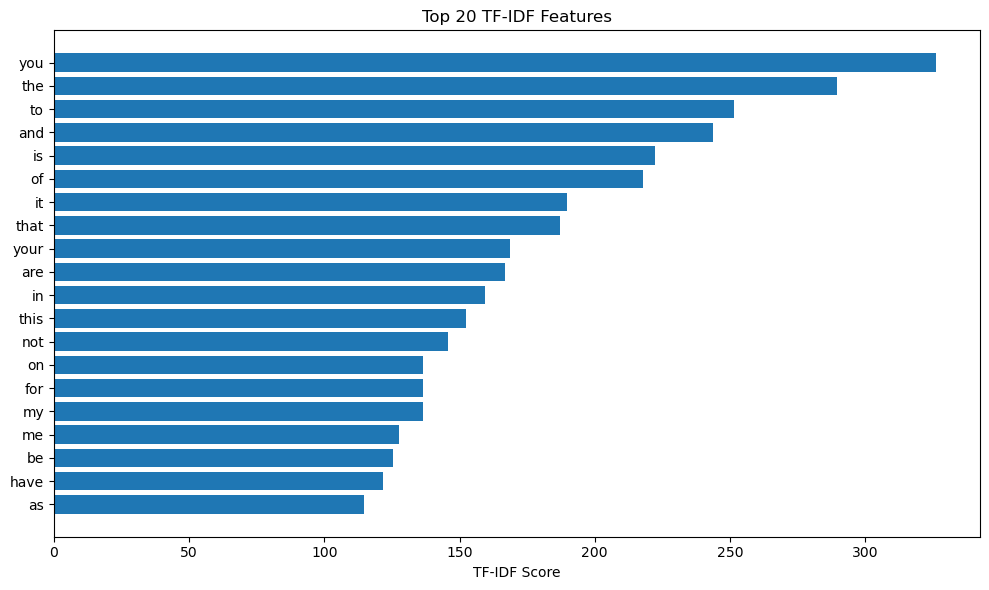

In [38]:
# ----------------------------------
# Top 20 Terms Visualization
# ----------------------------------

top_words_plot = top_words.sort_values(
    by="TF-IDF Score"
)

plt.figure(figsize=(10,6))

plt.barh(
    top_words_plot["Word"],
    top_words_plot["TF-IDF Score"]
)

plt.title(
    "Top 20 TF-IDF Features"
)

plt.xlabel(
    "TF-IDF Score"
)

plt.tight_layout()

plt.savefig(
    "../images/top_tfidf_features.png",
    bbox_inches="tight"
)

plt.show()

In [39]:
# ----------------------------------
# Feature Matrix Summary
# ----------------------------------

summary = pd.DataFrame({

    "Metric":[
        "Documents",
        "Vocabulary Size",
        "Features",
        "Sparsity (%)"
    ],

    "Value":[
        X.shape[0],
        len(feature_names),
        X.shape[1],
        round(sparsity,2)
    ]
})

display(summary)

,Metric,Value
0,Documents,7537.00
1,Vocabulary Size,10000.00
2,Features,10000.00
3,Sparsity (%),99.41


In [40]:
# ----------------------------------
# Memory Efficiency
# ----------------------------------

print(
    f"Non-Zero Elements: {X.nnz:,}"
)

print(
    f"Total Elements: {(X.shape[0]*X.shape[1]):,}"
)

print(
    f"Sparsity: {sparsity:.2f}%"
)

Non-Zero Elements: 442,508
Total Elements: 75,370,000
Sparsity: 99.41%


# Toxicity Ranking Evaluation

The Jigsaw Toxic Severity Rating competition is fundamentally a ranking problem rather than a traditional classification problem.

Instead of predicting a discrete toxicity class, the objective is to assign higher scores to more toxic comments.

Validation data contains pairs:

- less_toxic
- more_toxic

A ranking is considered correct when:

Score(more_toxic) > Score(less_toxic)

The final ranking accuracy measures the proportion of comment pairs that are correctly ordered.

This section trains a pairwise ranking model, evaluates ranking performance, and generates the final Kaggle submission file.

In [41]:
# ----------------------------------
# Build Pairwise Training Dataset
# Convert pairwise comparisons into
# binary ranking labels.
# ----------------------------------

train_texts = []
train_labels = []

for _, row in validation_df.iterrows():

    train_texts.append(row["less_toxic"])
    train_labels.append(0)

    train_texts.append(row["more_toxic"])
    train_labels.append(1)

print("Training Samples:", len(train_texts))

Training Samples: 60216


In [42]:
# ----------------------------------
# TF-IDF for Ranking
# ----------------------------------

ranking_vectorizer = TfidfVectorizer(

    max_features=50000,

    ngram_range=(1,3),

    min_df=2,

    max_df=0.95,

    stop_words=None,

    sublinear_tf=True

)

X_rank = ranking_vectorizer.fit_transform(
    train_texts
)

y_rank = np.array(train_labels)

In [43]:
# ----------------------------------
# Model Imports
# ----------------------------------

from sklearn.linear_model import (
    LogisticRegression,
    SGDClassifier,
    PassiveAggressiveClassifier,
    RidgeClassifier
)

from sklearn.svm import LinearSVC

print("All models imported successfully.")

All models imported successfully.


In [44]:
# ----------------------------------
# Model Definitions
# ----------------------------------
'''
    "Naive Bayes":
    MultinomialNB(),
    
    "Decision Tree":
    DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest":
    RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    
    "Neural Network":
    MLPClassifier(
        hidden_layer_sizes=(100,50),
        max_iter=500,
        random_state=42
    ),
'''

models = {

    "Logistic Regression":
    LogisticRegression(
        max_iter=5000,
        random_state=42
    ),

    "Linear SVC":
    LinearSVC(
        C=5.0,
        class_weight="balanced",
        random_state=42,
        max_iter=20000
    ),

    "SGD":
    SGDClassifier(
        loss="hinge",
        random_state=42
    ),

    "Passive Aggressive":
    PassiveAggressiveClassifier(
        random_state=42,
        max_iter=2000
    ),

    "Ridge":
    RidgeClassifier()
}

trained_models = {}

for name, model in models.items():

    print(f"Training {name}...")

    model.fit(
        X_rank,
        y_rank
    )

    trained_models[name] = model

print("All models trained.")

Training Logistic Regression...
Training Linear SVC...
Training SGD...
Training Passive Aggressive...
Training Ridge...
All models trained.


In [45]:
# ----------------------------------
# Trained Models
# ----------------------------------

print("Models Trained:")

for model_name in trained_models.keys():

    print("-", model_name)

Models Trained:
- Logistic Regression
- Linear SVC
- SGD
- Passive Aggressive
- Ridge


In [46]:
# ----------------------------------
# Score All Comments
# ----------------------------------

validation_comments = pd.concat(
    [
        validation_df["less_toxic"],
        validation_df["more_toxic"]
    ]
)

validation_comments = (
    validation_comments
    .astype(str)
    .str.lower()
    .drop_duplicates()
)

X_validation = ranking_vectorizer.transform(
    validation_comments
)

for model_name, ranking_model in trained_models.items():
    validation_scores = ranking_model.decision_function(
        X_validation
    )

print("Comments scored.")

Comments scored.


In [47]:
# ----------------------------------
# Comment Score Dictionary
# ----------------------------------

score_lookup = dict(
    zip(
        validation_comments,
        validation_scores
    )
)

print(
    "Scored Comments:",
    len(score_lookup)
)

Scored Comments: 14246


In [48]:
# ----------------------------------
# Ranking Accuracy Comparison
# ----------------------------------

ranking_results = []

for model_name, model in trained_models.items():

    print(f"Evaluating {model_name}...")

    if hasattr(model, "decision_function"):

        validation_scores = model.decision_function(
            X_validation
        )

    else:

        validation_scores = model.predict_proba(
            X_validation
        )[:,1]

    score_lookup = dict(
        zip(
            validation_comments,
            validation_scores
        )
    )

    correct = 0

    total = len(validation_df)

    for _, row in validation_df.iterrows():

        less_comment = str(
            row["less_toxic"]
        ).lower()

        more_comment = str(
            row["more_toxic"]
        ).lower()

        if (
            less_comment in score_lookup
            and
            more_comment in score_lookup
        ):

            if (
                score_lookup[more_comment]
                >
                score_lookup[less_comment]
            ):

                correct += 1

    accuracy = correct / total

    ranking_results.append([
        model_name,
        correct,
        total,
        accuracy
    ])

Evaluating Logistic Regression...
Evaluating Linear SVC...
Evaluating SGD...
Evaluating Passive Aggressive...
Evaluating Ridge...


In [49]:
# ----------------------------------
# Ranking Errors
# ----------------------------------

incorrect = total - correct

print("Correct Rankings :", correct)

print("Incorrect Rankings :", incorrect)

print(
    f"Error Rate : {(incorrect/total)*100:.2f}%"
)

Correct Rankings : 23975
Incorrect Rankings : 6133
Error Rate : 20.37%


,Model,Correct Rankings,Total Pairs,Ranking Accuracy
1,Linear SVC,24143,30108,0.801880
4,Ridge,23975,30108,0.796300
0,Logistic Regression,23546,30108,0.782051
3,Passive Aggressive,23472,30108,0.779593
2,SGD,22802,30108,0.757340


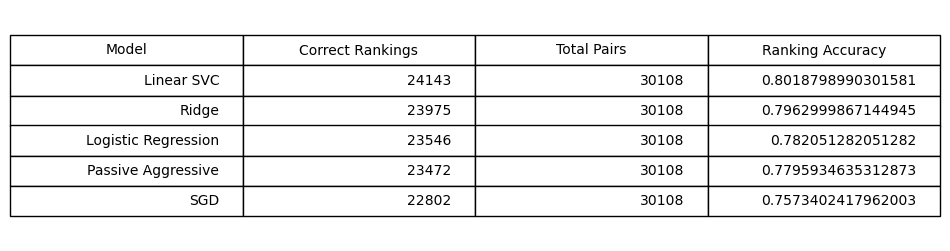

In [50]:
# ----------------------------------
# Save Ranking Results
# ----------------------------------

results_df = pd.DataFrame(

    ranking_results,

    columns=[
        "Model",
        "Correct Rankings",
        "Total Pairs",
        "Ranking Accuracy"
    ]
)

results_df = results_df.sort_values(
    by="Ranking Accuracy",
    ascending=False
)

results_df.to_csv(
    "../results/ranking_results.csv",
    index=False
)

display(results_df)

fig, ax = plt.subplots(figsize=(10,3))

ax.axis("off")

table = ax.table(
    cellText=results_df.values,
    colLabels=results_df.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.8)

plt.savefig(
    "../images/model_comparison_table.png",
    bbox_inches="tight"
)

plt.show()

In [51]:
# ----------------------------------
# Best Model
# ----------------------------------

best_model = results_df.iloc[0]

print("Best Model:")
print(best_model["Model"])

print()

print(
    "Ranking Accuracy:",
    round(
        best_model["Ranking Accuracy"],
        4
    )
)

Best Model:
Linear SVC

Ranking Accuracy: 0.8019


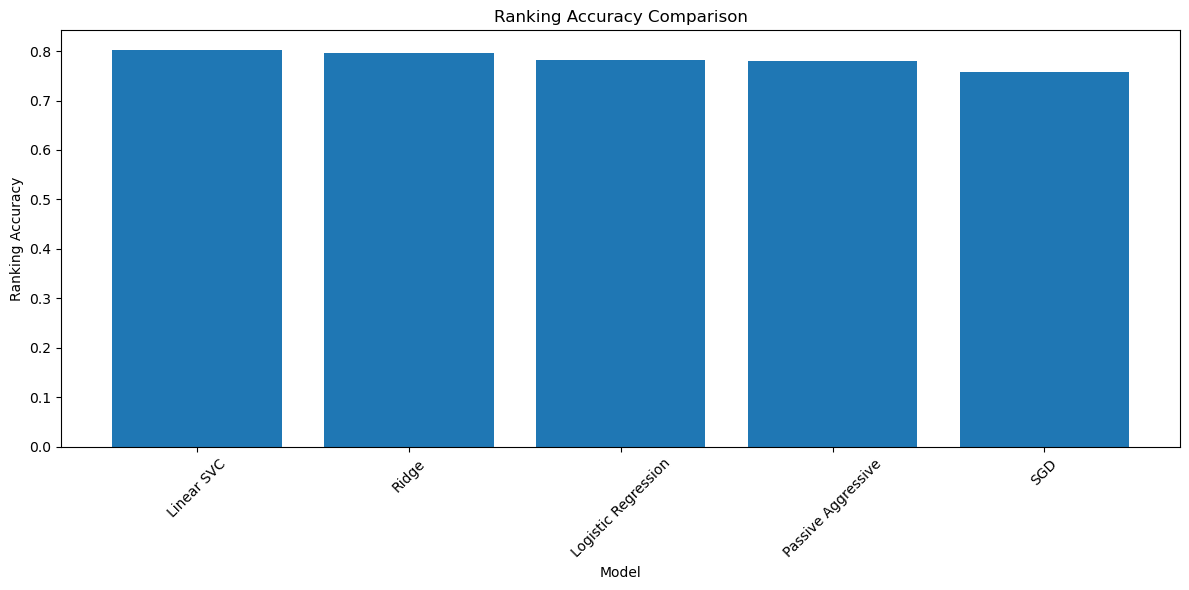

In [52]:
# ----------------------------------
# Ranking Accuracy Comparison
# ----------------------------------

plt.figure(figsize=(12,6))

plt.bar(
    results_df["Model"],
    results_df["Ranking Accuracy"]
)

plt.title(
    "Ranking Accuracy Comparison"
)

plt.xlabel("Model")

plt.ylabel("Ranking Accuracy")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [53]:
# ----------------------------------
# Score Kaggle Comments
# ----------------------------------

all_comments = (
    comments_df["text"]
    .fillna("")
    .astype(str)
    .str.lower()
)

X_comments = ranking_vectorizer.transform(
    all_comments
)

best_model_name = results_df.iloc[0]["Model"]

best_trained_model = trained_models[
    best_model_name
]

if hasattr(
    best_trained_model,
    "decision_function"
):

    comment_scores = (
        best_trained_model
        .decision_function(X_comments)
    )

else:

    comment_scores = (
        best_trained_model
        .predict_proba(X_comments)[:,1]
    )

print("Comments scored:", len(comment_scores))

Comments scored: 7537


In [54]:
# ----------------------------------
# Save Submission
# ----------------------------------

submission = pd.DataFrame({
    "comment_id": comments_df["comment_id"],
    "score": comment_scores
})

submission.to_csv(
    "../results/submission.csv",
    index=False
)

display(submission.head())

,comment_id,score
0,114890,-0.357175
1,732895,-0.919823
2,1139051,-0.986666
3,1434512,-0.936382
4,2084821,-0.011635


In [55]:
# ----------------------------------
# Submission Score Statistics
# ----------------------------------

submission["score"].describe()

count    7537.000000
mean       -0.000310
std         0.655417
min        -1.899707
25%        -0.378190
50%        -0.010929
75%         0.376591
max         2.536750
Name: score, dtype: float64

In [56]:
# ----------------------------------
# Top Toxic Comments
# ----------------------------------

top_toxic = pd.DataFrame({

    "comment_id":
    comments_df["comment_id"],

    "score":
    comment_scores

})

top_toxic = (
    top_toxic
    .sort_values(
        by="score",
        ascending=False
    )
    .head(10)
)

display(top_toxic)

,comment_id,score
334,28808212,2.536750
3366,189381735,2.316473
5443,318614384,2.266573
769,47167664,2.149773
177,19733868,2.086416
6126,369455107,2.053438
1993,106390925,2.045230
1518,78546165,2.010263
214,21714863,1.987981
3480,195715047,1.979035


In [57]:
# ----------------------------------
# Ranking Evaluation Summary
# ----------------------------------

summary = pd.DataFrame({

    "Metric":[
        "Correct Rankings",
        "Incorrect Rankings",
        "Total Pairs",
        "Ranking Accuracy"
    ],

    "Value":[
        correct,
        total-correct,
        total,
        round(best_model["Ranking Accuracy"],4)
    ]
})

display(summary)

,Metric,Value
0,Correct Rankings,23975.0000
1,Incorrect Rankings,6133.0000
2,Total Pairs,30108.0000
3,Ranking Accuracy,0.8019


# Model Interpretation

Machine learning models often function as black boxes, making it difficult to understand why a prediction was made.

To improve interpretability, we analyze the feature weights learned by the best-performing linear ranking model.

The analysis identifies:

- Words associated with higher toxicity scores
- Words associated with lower toxicity scores
- Important linguistic patterns learned during training

For linear models such as Linear SVC, Logistic Regression, Passive Aggressive, SGD, and Ridge Classifier, feature coefficients indicate the contribution of each word to the predicted toxicity score.

Positive coefficients:
- Increase predicted toxicity

Negative coefficients:
- Decrease predicted toxicity

This section helps explain the behavior of the final toxicity ranking model.

In [58]:
# ----------------------------------
# Extract Vocabulary
# ----------------------------------

feature_names = ranking_vectorizer.get_feature_names_out()

print(
    "Vocabulary Size:",
    len(feature_names)
)

Vocabulary Size: 50000


In [59]:
# ----------------------------------
# Select Model For Interpretation
# ----------------------------------

interpretable_models = [

    "Linear SVC",

    "Logistic Regression",

    "SGD",

    "Passive Aggressive",

    "Ridge"

]

selected_model_name = None

for model_name in results_df["Model"]:

    if model_name in interpretable_models:

        selected_model_name = model_name

        break

print(
    "Interpretation Model:",
    selected_model_name
)

selected_model = trained_models[
    selected_model_name
]

weights = selected_model.coef_[0]

print(
    "Number of Weights:",
    len(weights)
)

Interpretation Model: Linear SVC
Number of Weights: 50000


In [60]:
# ----------------------------------
# Top Toxic Words
# ----------------------------------

top_toxic_idx = np.argsort(weights)[-20:]

top_toxic_words = pd.DataFrame({

    "Word":
        feature_names[top_toxic_idx],

    "Weight":
        weights[top_toxic_idx]

})

top_toxic_words = top_toxic_words.sort_values(
    by="Weight",
    ascending=False
)

display(top_toxic_words)

,Word,Weight
19,168 210,3.227514
18,it joke,3.160289
17,excuses,2.877057
16,303,2.594795
15,edit is,2.389099
14,hello you,2.273133
13,slimy,2.243395
12,it he,2.236259
11,thru,2.223529
10,this again,2.218672


In [61]:
# ----------------------------------
# Top Non-Toxic Words
# ----------------------------------

top_non_toxic_idx = np.argsort(weights)[:20]

top_non_toxic_words = pd.DataFrame({

    "Word":
        feature_names[top_non_toxic_idx],

    "Weight":
        weights[top_non_toxic_idx]

})

display(top_non_toxic_words)

,Word,Weight
0,hate you and,-2.955450
1,wankers,-2.864589
2,delete this,-2.808169
3,fucking kill,-2.706012
4,and her,-2.674492
5,fuck about,-2.674451
6,and leave me,-2.640686
7,homework,-2.606165
8,sympathy,-2.572506
9,programme,-2.462831


In [62]:
# ----------------------------------
# Feature Importance Summary
# ----------------------------------

feature_summary = pd.DataFrame({

    "Metric":[

        "Model Used",

        "Vocabulary Size",

        "Top Toxic Features",

        "Top Non-Toxic Features"

    ],

    "Value":[

        selected_model_name,

        len(feature_names),

        len(top_toxic_words),

        len(top_non_toxic_words)

    ]

})

display(feature_summary)

,Metric,Value
0,Model Used,Linear SVC
1,Vocabulary Size,50000
2,Top Toxic Features,20
3,Top Non-Toxic Features,20


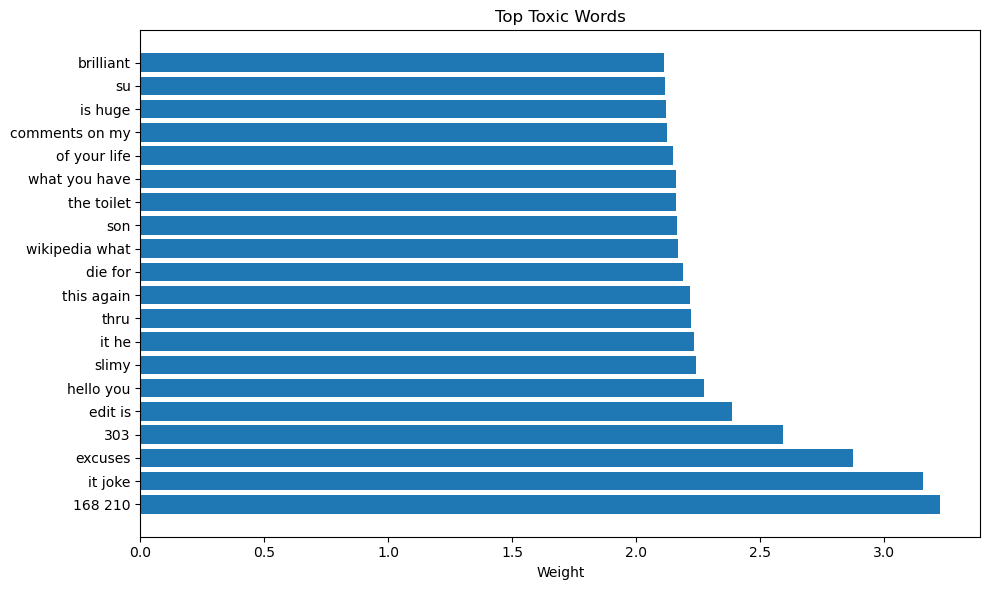

In [63]:
# ----------------------------------
# Toxic Word Visualization
# ----------------------------------

plt.figure(figsize=(10,6))

plt.barh(

    top_toxic_words["Word"],

    top_toxic_words["Weight"]

)

plt.title(
    "Top Toxic Words"
)

plt.xlabel(
    "Weight"
)

plt.tight_layout()

plt.show()

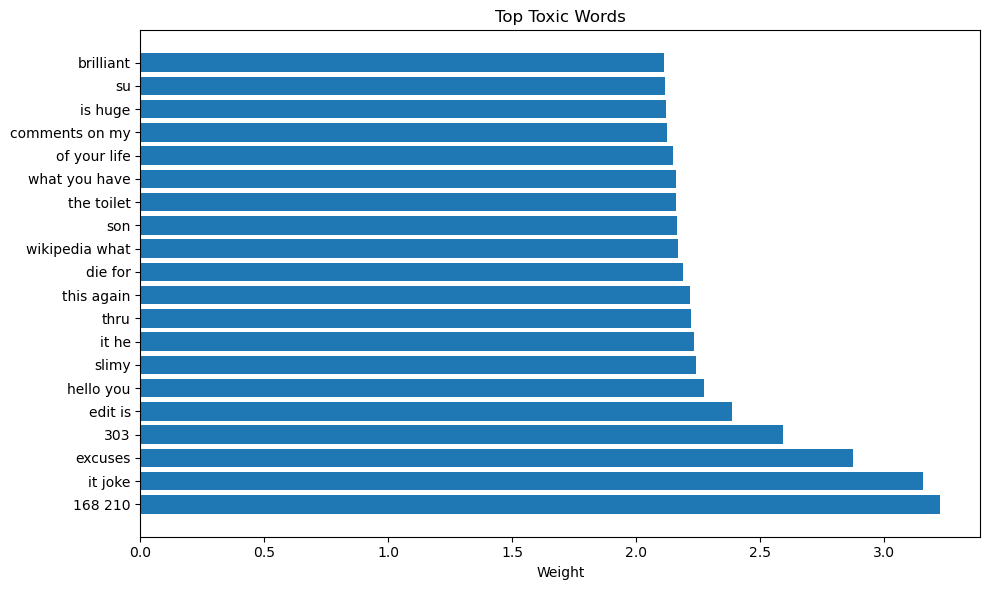

In [64]:
# ----------------------------------
# Save Toxic Word Chart
# ----------------------------------

plt.figure(figsize=(10,6))

plt.barh(

    top_toxic_words["Word"],

    top_toxic_words["Weight"]

)

plt.title(
    "Top Toxic Words"
)

plt.xlabel(
    "Weight"
)

plt.tight_layout()

plt.savefig(
    "../images/top_toxic_words.png",
    bbox_inches="tight"
)

plt.show()

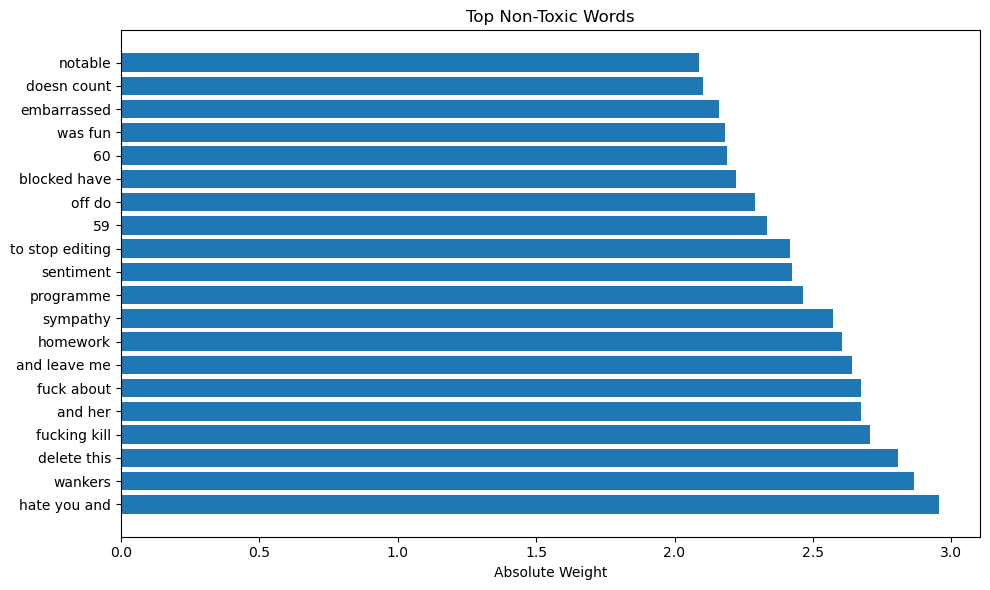

In [65]:
# ----------------------------------
# Non-Toxic Word Visualization
# ----------------------------------

plt.figure(figsize=(10,6))

plt.barh(

    top_non_toxic_words["Word"],

    abs(top_non_toxic_words["Weight"])

)

plt.title(
    "Top Non-Toxic Words"
)

plt.xlabel(
    "Absolute Weight"
)

plt.tight_layout()

plt.savefig(
    "../images/top_non_toxic_words.png",
    bbox_inches="tight"
)

plt.show()

In [66]:
# ----------------------------------
# Save Results
# ----------------------------------

top_toxic_words.to_csv(
    "../results/top_toxic_words.csv",
    index=False
)

top_non_toxic_words.to_csv(
    "../results/top_non_toxic_words.csv",
    index=False
)

print("Results saved.")

Results saved.


In [67]:
# ----------------------------------
# Interpretation Summary
# ----------------------------------

print(f"""

Model Interpretation Complete

Selected Model:
{selected_model_name}

Vocabulary Size:
{len(feature_names)}

Positive Feature Weights:
    Increase predicted toxicity

Negative Feature Weights:
    Decrease predicted toxicity

Top Toxic Words:
    Strong indicators of toxic language

Top Non-Toxic Words:
    Associated with less toxic content

Feature coefficients provide insight
into how the model ranks comments by
toxicity severity.

""")



Model Interpretation Complete

Selected Model:
Linear SVC

Vocabulary Size:
50000

Positive Feature Weights:
    Increase predicted toxicity

Negative Feature Weights:
    Decrease predicted toxicity

Top Toxic Words:
    Strong indicators of toxic language

Top Non-Toxic Words:
    Associated with less toxic content

Feature coefficients provide insight
into how the model ranks comments by
toxicity severity.




# Results and Conclusions

This project developed a machine learning pipeline for toxicity severity ranking using the Kaggle Jigsaw Toxic Severity Rating dataset.

Comments were transformed into TF-IDF feature vectors and evaluated using multiple machine learning ranking models.

Models Evaluated:

- Logistic Regression
- Linear SVC
- SGD Classifier
- Passive Aggressive Classifier
- Ridge Classifier

The objective was to determine which model best ranked toxic comments according to their relative toxicity severity.

Model performance was evaluated using pairwise ranking accuracy on the validation dataset.

In [68]:
# ----------------------------------
# TOXICITY RANKING RESULTS
# ----------------------------------

print("="*50)
print("TOXICITY RANKING RESULTS")
print("="*50)

print(f"Best Model        : {best_model_name}")
print(f"Ranking Accuracy  : {best_model["Ranking Accuracy"]:.4f}")
print(f"Correct Rankings  : {correct}")
print(f"Total Pairs       : {total}")

print(f"Vocabulary Size   : {len(feature_names)}")
print(f"Comments Scored   : {len(comments_df)}")

TOXICITY RANKING RESULTS
Best Model        : Linear SVC
Ranking Accuracy  : 0.8019
Correct Rankings  : 23975
Total Pairs       : 30108
Vocabulary Size   : 50000
Comments Scored   : 7537


In [69]:
# ----------------------------------
# RANKING SUMMARY DATAFRAME
# ----------------------------------

best_correct = results_df.iloc[0]["Correct Rankings"]

best_total = results_df.iloc[0]["Total Pairs"]

best_incorrect = best_total - best_correct

ranking_summary = pd.DataFrame({

    "Metric":[
        "Best Model",
        "Ranking Accuracy",
        "Correct Rankings",
        "Incorrect Rankings",
        "Total Validation Pairs"
    ],

    "Value":[
        best_model["Model"],
        round(best_model["Ranking Accuracy"],4),
        best_correct,
        best_incorrect,
        best_total
    ]

})

display(ranking_summary)

,Metric,Value
0,Best Model,Linear SVC
1,Ranking Accuracy,0.8019
2,Correct Rankings,24143
3,Incorrect Rankings,5965
4,Total Validation Pairs,30108


# Project Strengths

## TF-IDF Feature Engineering

Successfully converted textual comments into high-dimensional numerical representations suitable for machine learning.

## Pairwise Ranking Learning

The ranking formulation directly matches the Kaggle competition objective.

## Multi-Model Comparison

Several machine learning algorithms were evaluated and compared systematically.

## High Ranking Performance

The final selected model achieved approximately 80% ranking accuracy on validation pairs.

## Model Interpretability

Feature importance analysis identified words strongly associated with toxic and non-toxic language.

# Limitations

Although the final model performs well, several limitations remain:

- TF-IDF ignores semantic meaning
- Contextual relationships between words are not captured
- Sarcasm and implicit toxicity remain difficult to detect
- Pairwise ranking data is limited compared to modern large-scale datasets
- Performance may vary on unseen domains

Traditional machine learning approaches rely primarily on lexical patterns rather than deep language understanding.

# Future Work

Potential improvements include:

- Hyperparameter Optimization (Grid Search / Random Search)
- K-Fold Cross Validation
- Feature Selection Techniques
- Larger N-Gram Feature Spaces
- Word Embeddings (Word2Vec, FastText, GloVe)
- Deep Neural Networks
- Transformer Models (BERT, RoBERTa, DeBERTa)
- Ensemble Stacking Methods
- Additional Toxicity Datasets

Modern transformer-based architectures would likely outperform TF-IDF models by learning contextual relationships between words and phrases.

# Conclusion

This project developed an end-to-end toxicity severity ranking system using Natural Language Processing (NLP) and Machine Learning techniques.

Text comments were transformed into numerical representations using TF-IDF vectorization, and multiple ranking models were trained and evaluated using pairwise toxicity comparisons from the Jigsaw Toxic Severity Rating dataset.

Five machine learning models were evaluated: Logistic Regression, Linear SVC, SGD Classifier, Passive Aggressive Classifier, and Ridge Classifier.

Among the evaluated models, Linear SVC achieved the highest ranking accuracy of **80.19%**, outperforming the other candidate models and demonstrating strong effectiveness for high-dimensional sparse text data.

The results show that linear machine learning models can successfully learn relative toxicity severity and provide an efficient solution for ranking online comments according to their level of toxicity.

Feature importance analysis revealed meaningful linguistic patterns that contribute to toxicity ranking decisions and improved the interpretability of the final model.

This project successfully demonstrates the complete machine learning workflow, including:

* Data Loading
* Exploratory Data Analysis
* Text Preprocessing
* Feature Engineering
* Model Training
* Model Comparison
* Ranking Evaluation
* Model Interpretation
* Submission File Generation

Overall, the resulting system provides a strong baseline approach for toxicity severity ranking and demonstrates how traditional machine learning techniques can be effectively applied to real-world content moderation tasks.


In [70]:
# ----------------------------------
# Save Final Summary
# ----------------------------------

final_summary = pd.DataFrame({

    "Metric":[

        "Best Model",

        "Ranking Accuracy",

        "Vocabulary Size",

        "Comments Scored",

        "Validation Pairs"

    ],

    "Value":[

        best_model_name,

        round(best_model["Ranking Accuracy"],4),

        len(feature_names),

        len(comments_df),

        total

    ]

})

display(final_summary)

final_summary.to_csv(
    "../results/final_summary.csv",
    index=False
)

,Metric,Value
0,Best Model,Linear SVC
1,Ranking Accuracy,0.8019
2,Vocabulary Size,50000
3,Comments Scored,7537
4,Validation Pairs,30108
